# Lab 4.1: Edge Detection

In this lab you will experiment with edge detection techniques.

In [146]:
!wget -nc -qq -O giraffe-portrait.jpg "https://www.dropbox.com/scl/fi/mzohe12b6absepe92ovq8/giraffe-portrait.jpg?rlkey=go4vawy9c7rwm1zk3lfc78vl1&dl=1"

We will work with an image of a circle to test our edge detector code, and afterward test the `giraffe-portrait.jpg` image.

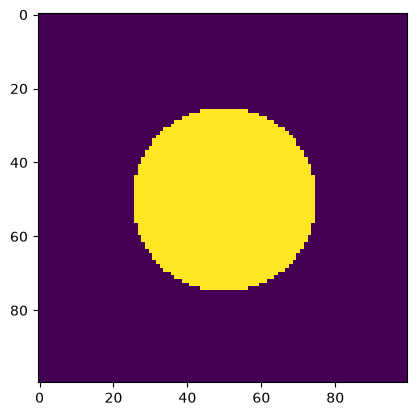

In [147]:
import cv2
import numpy as np
from skimage.draw import disk
from matplotlib import pyplot as plt

circle = np.zeros((100, 100))
r, c = disk((50, 50), 25)
circle[r, c] = 1

plt.imshow(circle)

# Exercises

1. Complete this function to compute the smoothed gradients $I_x=dI/dx$ and $I_y=dI/dy$:

- Gaussian blur the image (`skimage.filters.gaussian`) with the chosen $\sigma$ value
- Apply the derivative filters to compute $I_x$ and $I_y$
- Return $I_x$ and $I_y$

Test it on the circle image with sigma = 0 and sigma = 5 and show the results.

In [ ]:
from skimage.filters import gaussian
from scipy.ndimage import correlate

def compute_gradient_images(image,sigma):
    # YOUR CODE GOES HERE
    pass


2. Compute and show the gradient magnitude $\sqrt{I_x^2 + I_y^2}$ and gradient orientation $\tan^{-1}(I_y/I_x)$ images for sigma = 0 and sigma = 5.

*Note: use `np.atan2` to compute the gradient orientation.*

In [ ]:
# YOUR CODE GOES HERE

3. Complete this function to compute oriented non-max suppresion and label the edge pixels.

- Compute the gradient magnitude image and add `1e-8` to ensure that we don't divide by zero in the next step.
- Divide $I_x$ and $I_y$ by the gradient magnitude image to normalize the gradient vectors.
- Use the `make_grid` function to make a grid of image coordinates $x$, $y$
- Use the `grid_sample` function to sample the neighbor values in the gradient magnitude image at $(x+I_x,y+I_y)$ and $(x-I_x,y-I_y)$
- Return a Boolean array which is true wherever the gradient magnitude is above the threshold and greater than the two neighbor values

Test the NMS function on the sigma=0 and sigma=5 data and analyze the results.

In [ ]:
def make_grid(shape):
    y, x = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), indexing='ij')
    return x, y

def grid_sample(im,x,y):
    return cv2.remap(im, x.astype('float32'), y.astype('float32'), interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

def oriented_non_max(Ix, Iy, threshold=0.01):
    # YOUR CODE GOES HERE
    pass


YOUR TEXT GOES HERE

4. Now we will test on the `giraffe-portrait` image.

Hypothesize which edges in the image will detected with low and high levels of blur.

Try different settings of $\sigma$ from small to large.  Show the edge detection result for each image and analyze whether your hypotheses were correct.

In [158]:
from imageio.v3 import imread, imwrite
from skimage.color import rgb2gray

giraffe = imread('giraffe-portrait.jpg')
giraffe = giraffe.astype('float32')/255
giraffe_gray = rgb2gray(giraffe)

In [ ]:
# YOUR CODE GOES HERE

TEXT GOES HERE

5. Once you have everything working, you can play around with this code to make a stylized rendering of the image!

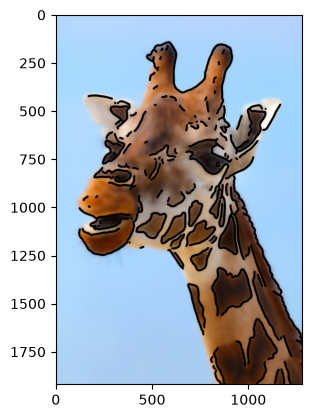

In [ ]:
from skimage.morphology import dilation, disk

# blur the color image
# blurred = gaussian(giraffe,sigma=7,channel_axis=-1)

# compute edges
# Ix, Iy = compute_gradient_images(giraffe_gray,sigma=7)
# nms = oriented_non_max(Ix,Iy,threshold=0.01)

# dilate edges
# nms = dilation(nms,footprint=disk(5))

# mark edge pixels as zero
# blurred[nms,:] = 0

# plt.imshow(blurred)
# imwrite('giraffe_stylized.jpg',(blurred*255).astype('uint8'))